In [20]:
%load_ext autoreload
%autoreload 2

import sys
import os
ISSM_DIR = os.getenv('ISSM_DIR') # for binaries

sys.path.append(ISSM_DIR + '/bin')
sys.path.append(ISSM_DIR + '/lib')
sys.path.append(ISSM_DIR + '/share')
sys.path.append(ISSM_DIR + '/share/proj')
sys.path.append(ISSM_DIR + '/src/m/contrib/jkjhew/')
sys.path.append('../source/')
sys.path.insert(0, '../scripts')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation 
from matplotlib import ticker
import matplotlib.colors as colors
from SetIceSheetBC import SetIceSheetBC
from SetMarineIceSheetBC import SetMarineIceSheetBC
from setflowequation import setflowequation
from generic import generic
from socket import gethostname
from toolkits import toolkits
from verbose import verbose
from solve import solve
from netCDF4 import Dataset
from m1qn3inversion import m1qn3inversion 
from marshall import marshall

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from triangle import triangle
from model import *
from netCDF4 import Dataset
from scipy.interpolate import RegularGridInterpolator
from InterpFromGridToMesh import InterpFromGridToMesh
from bamg import bamg
from ll2xy import ll2xy
from xy2ll import xy2ll
from plotmodel import plotmodel
from paterson import paterson
from setmask import setmask

# Step 1: Mesh generation
# Generate initial uniform mesh (resolution = 20000 m)
# project mesh onto new coordinate system
md = triangle(model(), './Ais.exp', 60000)
md.miscellaneous.name='AntarcticaGEOS'
md.mesh.epsg=3031

OSGeo/GDAL for Python not installed, overlay plots are not enabled


/Users/agstubbl/Desktop/ISSM/ISSM-binaries/bin/plotmodel.py:139: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


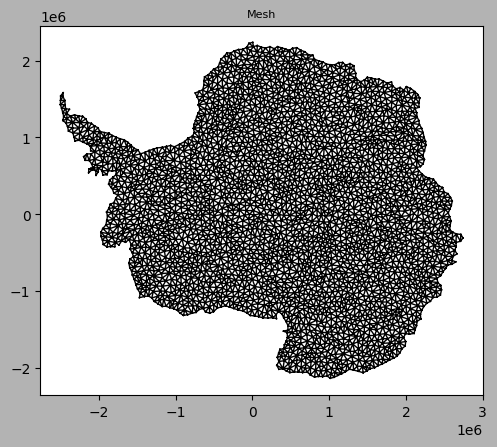

In [3]:
plotmodel(md,'data','mesh')

   Loading velocities data from NetCDF
Anisotropic mesh adaptation

   new number of triangles = 9430


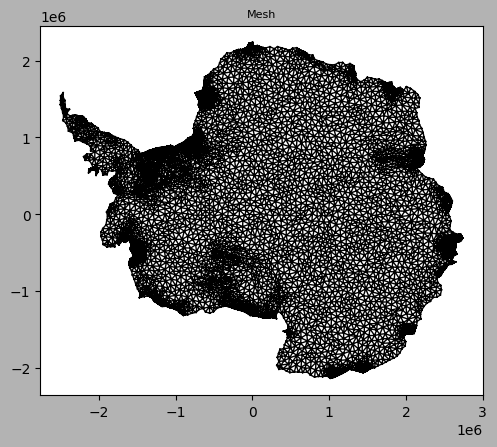

In [4]:
print('   Loading velocities data from NetCDF')
nsidc_vel = Dataset('../Data/Antarctica_ice_velocity.nc')
xmin = nsidc_vel.xmin
xmin = float(xmin.lstrip()[0:10])
ymax = nsidc_vel.ymax
ymax = float(ymax.lstrip()[0:10])
spacing = nsidc_vel.spacing
spacing = float((spacing.lstrip())[0:4])
nx = nsidc_vel.nx
ny = nsidc_vel.ny
velx = nsidc_vel['vx'][:].data
vely = nsidc_vel['vy'][:].data
# Build coordinates
x2 = xmin + np.arange(nx + 1) * spacing
y2 = (ymax - ny * spacing) + np.arange(ny + 1) * spacing

# print('   Set observed velocities')
md.initialization.vx = InterpFromGridToMesh(x2, y2, np.flipud(velx), md.mesh.x, md.mesh.y, 0)
md.initialization.vy = InterpFromGridToMesh(x2, y2, np.flipud(vely), md.mesh.x, md.mesh.y, 0)
md.initialization.vz = np.zeros(md.mesh.numberofvertices)
md.initialization.vel = np.sqrt(md.initialization.vx**2 + md.initialization.vy**2)
del velx, vely

md = bamg(md, 'hmax', 75000, 'hmin', 5000, 'gradation', 1.4, 'field', md.initialization.vel, 'err', 8)
plotmodel(md, 'data', 'mesh')

In [5]:
nodes = np.vstack([md.mesh.x,md.mesh.y]).T
conn = md.mesh.elements-1
triang = Triangulation(nodes[:,0]/1e3,nodes[:,1]/1e3,conn)

In [6]:
print('   Loading velocities data from NetCDF')
nsidc_vel = Dataset('../Data/Antarctica_ice_velocity.nc')
xmin = nsidc_vel.xmin
xmin = float(xmin.lstrip()[0:10])
ymax = nsidc_vel.ymax
ymax = float(ymax.lstrip()[0:10])
spacing = nsidc_vel.spacing
spacing = float((spacing.lstrip())[0:4])
nx = nsidc_vel.nx
ny = nsidc_vel.ny
velx = nsidc_vel['vx'][:].data
vely = nsidc_vel['vy'][:].data
# Build coordinates
x2 = xmin + np.arange(nx + 1) * spacing
y2 = (ymax - ny * spacing) + np.arange(ny + 1) * spacing

# print('   Set observed velocities')
md.initialization.vx = InterpFromGridToMesh(x2, y2, np.flipud(velx), md.mesh.x, md.mesh.y, 0)
md.initialization.vy = InterpFromGridToMesh(x2, y2, np.flipud(vely), md.mesh.x, md.mesh.y, 0)
md.initialization.vz = np.zeros(md.mesh.numberofvertices)
md.initialization.vel = np.sqrt(md.initialization.vx**2 + md.initialization.vy**2)
del velx, vely

   Loading velocities data from NetCDF


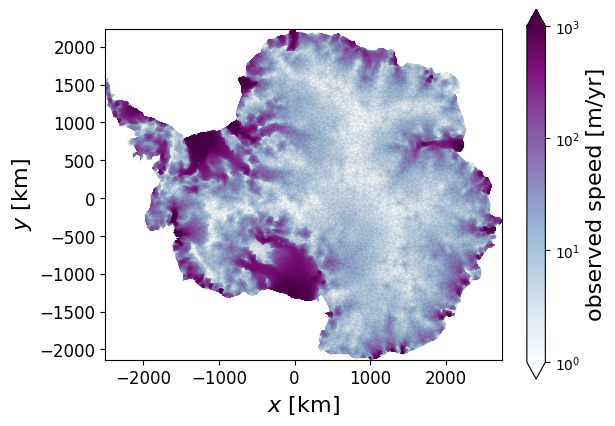

In [7]:
# plot observed speed interpolated onto mesh
p=plt.tricontourf(triang,md.initialization.vel+1e-3,cmap='BuPu',levels=np.logspace(0,3,100),locator=ticker.LogLocator(),norm=colors.LogNorm(),extend='both')
plt.triplot(triang.x, triang.y, triang.triangles,linewidth=1,color='k',alpha=0.1)
cbar = plt.colorbar(p,ticks=np.logspace(0,3,4))
cbar.set_label(r'observed speed [m/yr]',fontsize=16)
plt.ylabel(r'$y$ [km]', fontsize=16)
plt.xlabel(r'$x$ [km]', fontsize=16)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

In [8]:
# Parameters to change/Try
friction_coefficient = 10  # default [10]
Temp_change = 0           # default [0 K]

# NetCDF Loading
print('   Loading SeaRISE data from NetCDF')
ncdata = Dataset('../Data/Antarctica_5km_withshelves_v0.75.nc')
x1 = ncdata['x1'][:].data
y1 = ncdata['y1'][:].data
usrf = ncdata['usrf'][:].data[0]
topg = ncdata['topg'][:].data[0]
temp = ncdata['presartm'][:].data[0]
smb = ncdata['presprcp'][:].data[0]
gflux = ncdata['bheatflx_fox'][:].data[0]


   Loading SeaRISE data from NetCDF


In [9]:
# Geometry
print('   Interpolating surface and ice base')
md.geometry.base = InterpFromGridToMesh(x1, y1, topg, md.mesh.x, md.mesh.y, 0)
md.geometry.surface = InterpFromGridToMesh(x1, y1, usrf, md.mesh.x, md.mesh.y, 0)
del usrf, topg


   Interpolating surface and ice base


In [10]:
thkmask=ncdata['thkmask'][:].data[0]

##interpolate onto our mesh vertices
groundedice=   InterpFromGridToMesh(x1,y1,thkmask,md.mesh.x,md.mesh.y,0)
groundedice[groundedice<=0]=-1
del thkmask

#fill in the md.mask structure
md.mask.ocean_levelset = groundedice  #ice is grounded for mask equal one
md.mask.ice_levelset = -1*np.ones(np.shape(md.mesh.x))  #ice is present when negatvie


In [11]:
print('   Constructing thickness')
md.geometry.thickness = md.geometry.surface - md.geometry.base

# Ensure hydrostatic equilibrium on ice shelf
di = md.materials.rho_ice / md.materials.rho_water

# Get the node numbers of floating nodes
pos = np.where(md.mask.ocean_levelset < 0)

# Apply flotation criterion
md.geometry.thickness[pos] = 1 / (1 - di) * md.geometry.surface[pos]
md.geometry.base[pos] = md.geometry.surface[pos] - md.geometry.thickness[pos]
md.geometry.hydrostatic_ratio = np.ones(md.mesh.numberofvertices)  

# Set min thickness to 1 meter
pos0 = np.where(md.geometry.thickness <= 1)
md.geometry.thickness[pos0] = 1
md.geometry.surface = md.geometry.thickness + md.geometry.base
md.geometry.bed = md.geometry.base.copy()
md.geometry.bed[pos] = md.geometry.base[pos] - 1000

   Constructing thickness


In [12]:
# Initialization parameters
print('   Interpolating temperatures')
md.initialization.temperature = InterpFromGridToMesh(
    x1, y1, temp, md.mesh.x, md.mesh.y, 0
) + 273.15 + Temp_change


   Interpolating temperatures


In [13]:
[md.mesh.lat, md.mesh.long] = xy2ll(md.mesh.x, md.mesh.y, -1)

        xy2ll: creating coordinates in south polar stereographic (Std Latitude: 71degS Meridian: 0deg)


In [14]:

print('   Set Pressure')
md.initialization.pressure = md.materials.rho_ice * md.constants.g * md.geometry.thickness

print('   Construct ice rheological properties')
md.materials.rheology_n = 3 * np.ones(md.mesh.numberofelements)
md.materials.rheology_B = paterson(md.initialization.temperature)

# Forcings
print('   Interpolating surface mass balance')
mass_balance = InterpFromGridToMesh(x1, y1, smb, md.mesh.x, md.mesh.y, 0)
md.smb.mass_balance = mass_balance * md.materials.rho_water / md.materials.rho_ice

print('   Set geothermal heat flux')
md.basalforcings.geothermalflux = InterpFromGridToMesh(x1, y1, gflux, md.mesh.x, md.mesh.y, 0)

# Friction and inversion set up
print('   Construct basal friction parameters')
md.friction.coefficient = friction_coefficient * np.ones(md.mesh.numberofvertices)
md.friction.p = np.ones(md.mesh.numberofelements)
md.friction.q = np.ones(md.mesh.numberofelements)

# No friction applied on floating ice
pos = np.where(md.mask.ocean_levelset < 0)[0]
md.friction.coefficient[pos] = 0
md.groundingline.migration = 'SubelementMigration'

md.inversion = m1qn3inversion()
md.inversion.vx_obs = md.initialization.vx
md.inversion.vy_obs = md.initialization.vy
md.inversion.vel_obs = md.initialization.vel

print('   Set boundary conditions')
md = SetMarineIceSheetBC(md)
md.basalforcings.floatingice_melting_rate = np.zeros(md.mesh.numberofvertices)
md.basalforcings.groundedice_melting_rate = np.zeros(md.mesh.numberofvertices)
md.thermal.spctemperature = md.initialization.temperature
md.masstransport.spcthickness = np.full(md.mesh.numberofvertices, np.nan)

   Set Pressure
   Construct ice rheological properties
   Interpolating surface mass balance
   Set geothermal heat flux
   Construct basal friction parameters
empty init
   Set boundary conditions
      boundary conditions for stressbalance model: spc set as observed velocities
      no basalforcings.groundedice_melting_rate specified: values set as zero
      no basalforcings.floatingice_melting_rate specified: values set as zero
      no balancethickness.thickening_rate specified: values set as zero


In [15]:
md = setflowequation(md,'SSA','all')

In [16]:
md.inversion

   m1qn3inversion parameters:
         iscontrol              : 0               -- is inversion activated?
         incomplete_adjoint     : 1               -- 1: linear viscosity, 0: non - linear viscosity
         control_parameters     : 'FrictionCoe... -- ex: [FrictionCoefficient], or [MaterialsRheologyBbar]
         control_scaling_factors: 1               -- order of magnitude of each control (useful for multi - parameter optimization)
         maxsteps               : 20              -- maximum number of iterations (gradient computation)
         maxiter                : 40              -- maximum number of Function evaluation (forward run)
         dxmin                  : 0.1             -- convergence criterion: two points less than dxmin from eachother (sup - norm) are considered identical
         dfmin_frac             : 1.0             -- expected reduction of J during the first step (e.g., 0.3=30% reduction in cost function)
         gttol                  : 0.0001      

checking model consistency
marshalling file 'AntarcticaGEOS'.bin
launching solution sequence

Ice-sheet and Sea-level System Model (ISSM) version  4.24
(website: http://issm.jpl.nasa.gov forum: https://issm.ess.uci.edu/forum/)

call computational core:
   Initialize M1QN3 parameters
   Computing initial solution

┌────┬─────────────────┬────────────┬──────────────────────────────┐
│Iter│  Cost function  │ Grad. norm │  List of contributions       │
├────┼─────────────────┼────────────┼──────────────────────────────┤
   computing new velocity
   computing velocities
   computing adjoint
   saving results
│  1 │ f(x)= 3.358e+08 │   2.14e+05 │ 3.344e+08 1.446e+06  5.94e-06│
   computing new velocity
   computing velocities
   computing adjoint
   saving results
│  2 │ f(x)=3.3329e+08 │   2.17e+03 │ 3.319e+08 1.361e+06 3.663e-05│
   computing new velocity
   computing velocities
   computing adjoint
   saving results
│  3 │ f(x)=3.3323e+08 │   1.89e+03 │ 3.319e+08 1.318e+06 3.822e-05│
   c

/Users/agstubbl/Desktop/ISSM/ISSM-binaries/bin/plotmodel.py:139: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


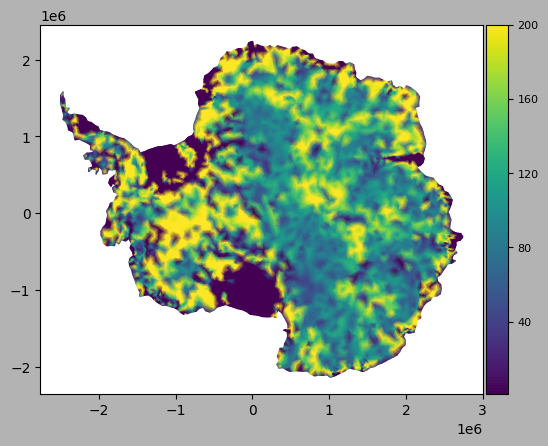

In [17]:
	# Control general
md.inversion.nsteps = 400
md.inversion.iscontrol=1
md.inversion.maxsteps=400
md.inversion.maxiter=400
md.inversion.dxmin=0.01
md.inversion.gttol=1.0e-8

# Cost functions
# md.inversion.cost_functions = [101,103, 501]
# md.inversion.cost_functions_coefficients=np.ones((md.mesh.numberofvertices,3))
# md.inversion.cost_functions_coefficients[:,0]=1
# md.inversion.cost_functions_coefficients[:,1]=1
# md.inversion.cost_functions_coefficients[:,2]=8e-15

md.inversion.step_threshold = 0.99 * np.ones((md.inversion.nsteps))
md.inversion.maxiter_per_step = 40 * np.ones((md.inversion.nsteps))

md.inversion.gradient_scaling = 50 * np.ones((md.inversion.nsteps, 1))
md.inversion.min_parameters = 1 * np.ones((md.mesh.numberofvertices, 1))
md.inversion.max_parameters = 200 * np.ones((md.mesh.numberofvertices, 1))

#Cost functions
md.inversion.cost_functions = [101, 103, 501]
md.inversion.cost_functions_coefficients = np.ones((md.mesh.numberofvertices, 3))
md.inversion.cost_functions_coefficients[:, 0] = 1
md.inversion.cost_functions_coefficients[:, 1] = 1
md.inversion.cost_functions_coefficients[:, 2] = 2e-10

# Controls
md.inversion.control_parameters = ['FrictionCoefficient']
md.inversion.min_parameters=1*np.ones(np.shape(md.mesh.x))
md.inversion.max_parameters=200*np.ones(np.shape(md.mesh.x))

# Additional parameters
md.stressbalance.restol=0.0000001
md.stressbalance.reltol=0.0000001
md.stressbalance.abstol=np.nan

# Solve
md.cluster = generic('name', gethostname(), 'np', 8)
md.toolkits = toolkits()
md.verbose = verbose('solution', True, 'control', True)
md = solve(md, 'Stressbalance')

# Update model friction fields accordingly
md.friction.coefficient=md.results.StressbalanceSolution.FrictionCoefficient

plotmodel(md,'data',md.friction.coefficient)

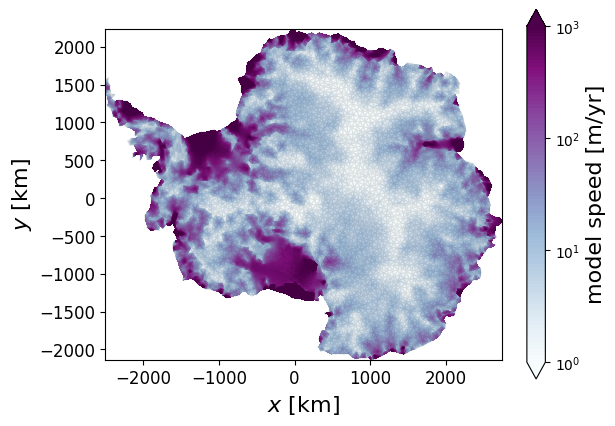

In [19]:
# plot observed speed interpolated onto mesh
p=plt.tricontourf(triang,md.results.StressbalanceSolution.Vel.flatten()+1e-3,cmap='BuPu',levels=np.logspace(0,3,100),locator=ticker.LogLocator(),norm=colors.LogNorm(),extend='both')
plt.triplot(triang.x, triang.y, triang.triangles,linewidth=1,color='k',alpha=0.1)
cbar = plt.colorbar(p,ticks=np.logspace(0,3,4))
cbar.set_label(r'model speed [m/yr]',fontsize=16)
plt.ylabel(r'$y$ [km]', fontsize=16)
plt.xlabel(r'$x$ [km]', fontsize=16)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

In [30]:

# Write the binary input file
# Additional options
md.transient.isthermal=0
md.inversion.iscontrol = 0
md.transient.requested_outputs = ['default']
md.settings.waitonlock = 0
md.private.solution = 'Transient'
md.verbose = verbose('000000000')
md.toolkits = toolkits()
marshall(md) # create .bin file
md.toolkits.ToolkitsFile(md.miscellaneous.name + '.toolkits')